# Machine Learning Notebook: Gradient Boosting for Regression (Mathematical Derivation)

Gradient Boosting is a sequential ensemble learning algorithm that builds a strong predictive model by **iteratively adding weak learners** (typically regression trees). Instead of fitting each new model to the original target values, every new model learns the **errors (pseudo-residuals)** made by the current ensemble.

---

# 1. Additive Modeling

Instead of learning one complex function directly, Gradient Boosting approximates the target function by **adding multiple weak learners sequentially**.

$$
f(x)=f_0(x)+f_1(x)+f_2(x)+\cdots+f_M(x)
$$

where

- $(f_0(x))$ = Initial prediction
- $(f_1(x),f_2(x),...)$ = Regression trees trained sequentially
- $(M)$ = Number of boosting iterations

Each new tree attempts to correct the mistakes made by the previous ensemble.

---

# 2. Input Requirements

Before training begins, Gradient Boosting requires:

### Training Dataset

$$
\{(x_i,y_i)\}_{i=1}^{n}
$$

where

- $(x_i)$ = Feature vector
- $(y_i)$ = Actual target value

---

### Differentiable Loss Function

Gradient Boosting requires a differentiable loss function.

For regression, the default loss is the **Mean Squared Error (MSE)**:

$$
\mathcal{L}(y_i,f(x_i))
=
\frac12
\left(y_i-f(x_i)\right)^2
$$
-
The factor of \(\frac12\) simplifies differentiation because it cancels the exponent coefficient.

---

# 3. Step 1 — Initialize the Base Predictor

The first model is **not a decision tree**.

Instead, Gradient Boosting finds a constant prediction that minimizes the total loss.

$$
f_0(x)
=
\arg\min_{\gamma}
\sum_{i=1}^{n}
\mathcal{L}(y_i,\gamma)
$$
-
Substituting the MSE loss:

$$
f_0(x)
=
\arg\min_{\gamma}
\sum_{i=1}^{n}
\frac12
(y_i-\gamma)^2
$$
---

## Differentiate

$$
\frac{\partial}{\partial \gamma}
\left[
\sum_{i=1}^{n}
\frac12
(y_i-\gamma)^2
\right]
=0
$$
-
Applying the chain rule,

$$
\sum_{i=1}^{n}
-(y_i-\gamma)=0
$$

Expanding,

$$
\sum_{i=1}^{n}y_i
-
n\gamma
=
0
$$
-
Therefore,

$$
\boxed{
\gamma
=
\frac1n
\sum_{i=1}^{n}
y_i
}
$$
-
---

## Final Result

For MSE loss,

$$
\boxed{
f_0(x)
=
\bar y
}
$$
-
where

$$
\bar y
=
\frac1n
\sum_{i=1}^{n}y_i
$$
-
Thus, the initial prediction is simply the **mean of the target values**.

---

# 4. Step 2 — Sequential Boosting

For each iteration

$$
m=1,2,\ldots,M
$$

Gradient Boosting performs four operations.

---

# Step 2a — Compute Pseudo-Residuals

The pseudo-residuals are the **negative gradient of the loss function**.

General form:

$$
r_{im}
=
\left[
\frac{\partial
\mathcal L(y_i,f(x_i))}
{\partial f(x_i)}
\right]
_{f=f_{m-1}}
$$
---

### Under MSE Loss

Differentiate:

$$
\frac{\partial}{\partial f(x_i)}
\left[
\frac12
(y_i-f(x_i))^2
\right]
=
-(y_i-f(x_i))
$$
-
Applying the negative sign,

$$
\boxed{
r_{im}
=
y_i-f_{m-1}(x_i)
}
$$
---

### Interpretation

For MSE,

Pseudo-residuals are simply

> **Actual Value − Current Prediction**

---

# Step 2b — Fit a Regression Tree

Train a regression tree using

- Input Features

$
x_i
$

- Target Values

$
r_{im}
$

The regression tree partitions the feature space into

$
J_m
$

terminal regions

$$
R_{1m},
R_{2m},
\ldots,
R_{J_mm}
$$

---

# Step 2c — Compute the Optimal Leaf Value

For every leaf region

$$
R_{jm}
$$

find the value that minimizes the loss.

$$
\gamma_{jm}
=
\arg\min_{\gamma}
\sum_{x_i\in R_{jm}}
\mathcal L
\left(
y_i,
f_{m-1}(x_i)+\gamma
\right)
$$
-
Substituting the MSE loss,

$$
\gamma_{jm}
=
\arg\min_{\gamma}
\sum_{x_i\in R_{jm}}
\frac12
\left(
y_i-
(f_{m-1}(x_i)+\gamma)
\right)^2
$$
-
Differentiate,

$$
\sum_{x_i\in R_{jm}}
-
\left(
y_i-f_{m-1}(x_i)-\gamma
\right)
=
0
$$
-
Using

$$
r_{im}
=
y_i-f_{m-1}(x_i)
$$
-
gives

$$
\sum_{x_i\in R_{jm}}
r_{im}
-
|R_{jm}|
\gamma
=
0
$$
-
Therefore,

$$
\boxed{
\gamma_{jm}
=
\frac
{\sum_{x_i\in R_{jm}}r_{im}}
{|R_{jm}|}
}
$$
---

## Interpretation

For MSE,

The optimal prediction for every leaf is simply the **average residual** of all samples inside that leaf.

---

# Step 2d — Update the Ensemble

Update the prediction function by adding the newly trained tree.
$$
\boxed{
f_m(x)
=
f_{m-1}(x)
+
\nu
\sum_{j=1}^{J_m}
\gamma_{jm}
\,
\mathbb I(x\in R_{jm})
}
$$
-
where

- $(\nu)$ = Learning Rate
- $(\gamma_{jm})$ = Leaf prediction
- $(\mathbb I(\cdot))$ = Indicator Function

---

## Indicator Function

$$
\mathbb I(x\in R_{jm})
=
\begin{cases}
1,&x\in R_{jm}\\
0,&\text{otherwise}
\end{cases}
$$
-
Only the leaf containing the sample contributes to the prediction.

---

# 5. Final Gradient Boosting Model

After completing all \(M\) boosting iterations, the final prediction function becomes

$$
\boxed{
f_M(x)
=
f_0(x)
+
\nu
\sum_{m=1}^{M}
\sum_{j=1}^{J_m}
\gamma_{jm}
\,
\mathbb I(x\in R_{jm})
}
$$
---

# Complete Algorithm

1. Initialize the model using the **mean target value**.
2. Compute pseudo-residuals.
3. Train a regression tree on the residuals.
4. Compute the optimal prediction for every leaf.
5. Scale the tree using the learning rate.
6. Add the new tree to the ensemble.
7. Repeat until all boosting iterations are complete.

---

# Key Mathematical Results

| Step | Formula | Interpretation |
|------|---------|----------------|
| Initial Model | $(f_0(x)=\bar y)$ | Mean of target values |
| Residual | $(r_{im}=y_i-f_{m-1}(x_i))$ | Actual − Prediction |
| Leaf Value | $(\gamma_{jm}=\dfrac{\sum r_{im}}{|R_{jm}|})$ | Mean residual inside a leaf |
| Model Update | $(f_m(x)=f_{m-1}(x)+\nu \sum \gamma_{jm}\mathbb I(x\in R_{jm}))$ | Add scaled tree |
| Final Model | $(f_M(x)=f_0(x)+\nu\sum_{m=1}^{M}\sum_{j=1}^{J_m}\gamma_{jm}\mathbb I(x\in R_{jm}))$ | Complete Gradient Boosting model |

In [1]:
# Lets Understand all this via Code

In [14]:
import pandas as pd

# 1. Create the data dictionary
data = {
    "R&D Spend": [165.0, 101.0, 29.0],
    "Administration": [137.0, 92.0, 127.0],
    "Marketing Spend": [472.0, 250.0, 201.0],
    "Profit": [192.0, 144.0, 91.0]
}

# 2. Define the custom indices matching your image
indices = [0, 11, 36]

# 3. Create the DataFrame
df = pd.DataFrame(data, index=indices)

# 4. Display the DataFrame
df

,R&D Spend,Administration,Marketing Spend,Profit
0,165.0,137.0,472.0,192.0
11,101.0,92.0,250.0,144.0
36,29.0,127.0,201.0,91.0


In [25]:
# input cols = R&D Spend,Administration , Marketing Spend
# output / target col = Profit

In [26]:
# Step 1
df['f0(x)'] = df['Profit'].mean()

In [27]:
df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),ri1
0,165.0,137.0,472.0,192.0,142.333333,49.666667
11,101.0,92.0,250.0,144.0,142.333333,1.666667
36,29.0,127.0,201.0,91.0,142.333333,-51.333333


In [28]:
# Step 2a 
df['ri1'] = df['Profit'] - df['f0(x)']

df

,R&D Spend,Administration,Marketing Spend,Profit,f0(x),ri1
0,165.0,137.0,472.0,192.0,142.333333,49.666667
11,101.0,92.0,250.0,144.0,142.333333,1.666667
36,29.0,127.0,201.0,91.0,142.333333,-51.333333


In [29]:
# now for next steps we'll need DT as our model 
from sklearn.tree import DecisionTreeRegressor  

In [30]:
dt1 = DecisionTreeRegressor(max_depth=1) 
# max_depth = Braches 

In [31]:
# Step 2b

# lets train our model 1 
dt1.fit(df.iloc[:,0:3].values , df['ri1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

[Text(0.5, 0.75, 'x[0] <= 65.0\nsquared_error = 1701.556\nsamples = 3\nvalue = -0.0'),
 Text(0.25, 0.25, 'squared_error = 0.0\nsamples = 1\nvalue = -51.333'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 576.0\nsamples = 2\nvalue = 25.667'),
 Text(0.625, 0.5, '  False')]

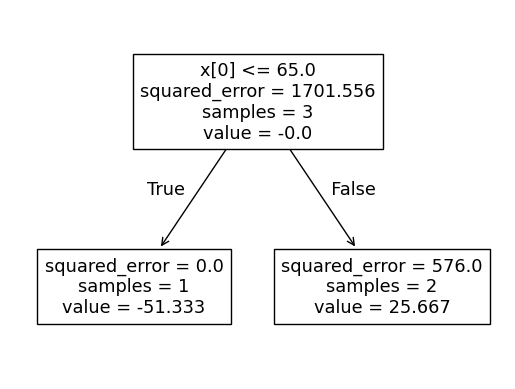

In [32]:
# Lets see the dt1 tree 
from sklearn.tree import plot_tree 
plot_tree(dt1)

# After this , we so same thing over and over again -> Result , We Get our Gradient Boosting  
# this is just an Intution How GB works , but we'll gonna use sklearn where all this steps are covered in single function 

### for better understanding of how we get these value & how we use these formulas to get these results   

watch this vid : https://youtu.be/nMNiTZm-qY0?si=ntJm3sX-lGxvWtCI 